In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

This notebook contains the homework 2 of the Machine Learning Zoomcamp 2026. Assignments are shown in this link https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/cohorts/2026/homework/02-regression/homework.md

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

In [78]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [9]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='object')

In [10]:
df.shape

(10000, 11)

In [11]:
df.dtypes

model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

For data manipulation purposes, it is common to unify the format of column names and string variables. Tipically, we set all strings to lower case and spaces to underscores. Use the "apply()" function to operate over an entire data frame. If applying to just a column, or the column names themselves, apply the function directly to it.

In [81]:
df[df.columns[df.dtypes == 'object']] = df[df.columns[df.dtypes == 'object']].apply(lambda x: x.str.lower().str.replace(' ', '_'))
df.rename(columns=lambda x: x.lower().replace(' ', '_'), inplace=True)
#df.columns[df.dtypes == 'object'] = df.columns[df.dtypes == 'object'].str.lower().str.replace(' ', '_')


Now, visualize some data using histograms. Here we are particularly interested in the fuel efficiency. As we can see, its distribution does not have heavy tails. Indeed, it seems to be Gaussian. We can check this through a quantity called kurtosis, defined as (Fisher's definition)

$
Kurt(X) = \frac{\langle X^4 \rangle}{\langle X^2 \rangle^2}-3,
$

which value is zero for a perfectly Gaussian distribution, positive for a heavy tailed distribution, and negative for a distribution with tails that decay faster than a Gaussian one. As we can see here, it has a small negative value, which means it has a slightly sub-Gaussian decay, confirming what we suspected by sight.

In [13]:
import seaborn as sns
from scipy.stats.mstats import kurtosis

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

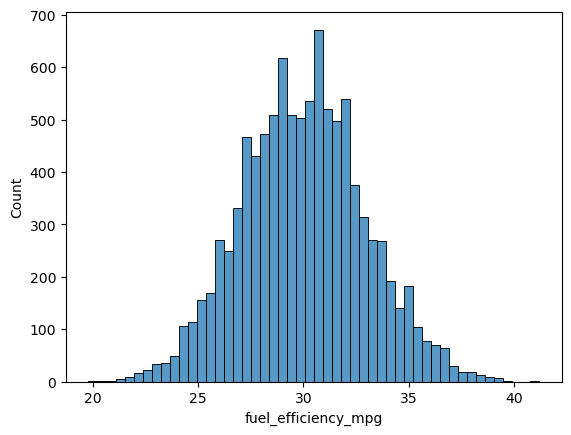

In [12]:
sns.histplot(data=df, x='fuel_efficiency_mpg', bins=50)

In [14]:
kurtosis(df.fuel_efficiency_mpg)

np.float64(-0.0708906528419102)

In [16]:
#logprice = np.log10(1 + df.fuel_efficiency_mpg)
#ax = sns.histplot(logprice, bins=50 )
#ax.set(xlabel='log(fuel_efficiency_mpg + 1)', ylabel='count', title='Histogram of log10(1 + fuel_efficiency_mpg)');

Let us prepare the data for training. First, we have to isolate the numerical variables. Then, we need to prepare these data to feed a training algorithm (remove Nan's and outliers). Don't forget to split the data set into a training and a validation subsets.

In [17]:
df[df.columns[df.dtypes != 'object']].dtypes

model_year               int64
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [82]:
#numframe = df[df.columns[df.dtypes != 'object']]
numframe = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
numframe.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

<span style="color: orange">Q1. There's one column among 'engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', with missing values. What is it?</span>


<span style="color: lightgreen">Ans.: The horsepower variable has missing values.</span>

Fill the NaN values with some numbers. Commom options are filling with zeros, and with the average of the remaining values.

In [27]:
numframe.horsepower.median()

254.0

<span style="color: orange">Q2. What's the median (50% percentile) for variable 'horsepower'?</span>

<span style="color: lightgreen">Ans.: The horsepower variable has a median (not the same as the mean) of 254.</span>

First, we try filling the missing values with the mean.

In [83]:
fillmean = False
if fillmean:
    numframe = numframe.fillna(numframe.mean())
else:
    numframe = numframe.fillna(0.)

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from scipy.linalg import lstsq

Split the dataset and train a linear model. I use the non-regularized least-squares solver lstsq. We validate with the test dataset.

In [79]:
def split_and_fill_missing(datframe, random_state=42):
    n = len(datframe)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(random_state)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = datframe.iloc[idx[:n_train]]
    df_val = datframe.iloc[idx[n_train:n_train + n_val]]
    df_test = datframe.iloc[idx[n_train + n_val:]]

    return df_train, df_val, df_test

In [84]:
df_train, df_val, df_test = split_and_fill_missing(numframe)

This is the result for missing values filled with the mean.

In [64]:
xsol = lstsq(df_train.drop(columns=['fuel_efficiency_mpg']), df_train.fuel_efficiency_mpg)
#Compute residuals and its mean square
res = df_val.drop(columns=['fuel_efficiency_mpg']).to_numpy() @ xsol[0] - df_val.fuel_efficiency_mpg.to_numpy()
print(f"RMSE score: {np.sqrt((res**2).mean())}")

#LinearRegressionModel = LinearRegression().fit(df_train.drop(columns=['fuel_efficiency_mpg']), df_train.fuel_efficiency_mpg)
#We use the R-squared score: $1-\sum_j(y_j^{pred} - y_j^{true})^2 / \sum_j(y_j^{pred} - \langle y_j^{pred} \rangle)^2$
#LinearRegressionModel.score(df_test.drop(columns=['fuel_efficiency_mpg']), df_test.fuel_efficiency_mpgp)

RMSE score: 2.440011749038366


And this for missing values filled with zeros.

In [85]:
xsol = lstsq(df_train.drop(columns=['fuel_efficiency_mpg']), df_train.fuel_efficiency_mpg)
#Compute residuals and its mean square
res = df_val.drop(columns=['fuel_efficiency_mpg']).to_numpy() @ xsol[0] - df_val.fuel_efficiency_mpg.to_numpy()
print(f"RMSE score: {np.sqrt((res**2).mean())}")

RMSE score: 2.430324278438264


<span style="color: orange">Q3. Which option gives better RMSE among filling with zeros and filling with the mean?</span>

<span style="color: lightgreen">Ans.: Filling with zeros gives a slightly better result.</span>

In [66]:
#root_mean_squared_error(LinearRegressionModel.predict(test.drop(columns=['msrp'])), test.msrp)

Now, we test with some regularization. For the problem of minimizing $|Ax - b|^2$, we use

$
x = (A^T.A + r \, I)^{-1}.A^T.b,
$

with $r$ some (usually small) parameter.

In [67]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [73]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
  b, a = train_linear_regression_reg(df_train.drop(columns=['fuel_efficiency_mpg']).values, df_train.fuel_efficiency_mpg.values, r=r)
  y_pred = b + df_val.drop(columns=['fuel_efficiency_mpg']).values.dot(a)
  print(f"r={r}, RMSE={root_mean_squared_error(y_pred, df_val.fuel_efficiency_mpg.values)}")

r=0, RMSE=2.205293194749885
r=0.01, RMSE=2.2058276166735173
r=0.1, RMSE=2.2241432777875016
r=1, RMSE=2.3492288883931556
r=5, RMSE=2.4093801665996724
r=10, RMSE=2.419469865473253
r=100, RMSE=2.429202138016242


<span style="color: orange">Q4. Which r gives the best RMSE?</span>

<span style="color: lightgreen">Ans.: Using no regularization (r=0) gave the best results.</span>

Now, let's test how much the sampling affects the quality of the fitted model.

Visualize a histogram of the predicted values and compare with the actual values.

In [87]:
RMSEscores = []
for seed in range(10):
  df_train, df_val, df_test = split_and_fill_missing(numframe, random_state=seed)
  #LinRegZero = LinearRegression().fit(train.drop(columns=['fuel_efficiency_mpg']), train.fuel_efficiency_mpg)
  #rmse = root_mean_squared_error(LinRegZero.predict(validation.drop(columns=['fuel_efficiency_mpg'])), validation.fuel_efficiency_mpg)
  xsol = lstsq(df_train.drop(columns=['fuel_efficiency_mpg']), df_train.fuel_efficiency_mpg)
  res = df_val.drop(columns=['fuel_efficiency_mpg']).to_numpy() @ xsol[0] - df_val.fuel_efficiency_mpg.to_numpy()
  rmse = np.sqrt((res**2).mean())
  RMSEscores.append(rmse)

np.std(RMSEscores)

np.float64(0.036108604940081154)

<span style="color: orange">Q5. What's the value of std of the RMSE score for the set of seeds used?</span>

<span style="color: lightgreen">Ans.: 0.036.</span>

In [93]:
df_train, df_val, df_test = split_and_fill_missing(numframe, random_state=9)
df_combined = pd.concat([df_train, df_val])
b, a = train_linear_regression_reg(df_combined.drop(columns=['fuel_efficiency_mpg']).values, df_combined.fuel_efficiency_mpg.values, r=0.001)
y_pred = b + df_test.drop(columns=['fuel_efficiency_mpg']).values.dot(a)
print(f"RMSE={root_mean_squared_error(y_pred, df_test.fuel_efficiency_mpg.values)}")

RMSE=2.2358277471956116


<span style="color: orange">Q6. What's the RMSE on the test dataset after combinig train and validation datasets?</span>

<span style="color: lightgreen">Ans.: 2.236.</span>

Ignore the following cells. They are just notes.

In [ ]:
df = pd.read_csv("C:\\Users\\Gigabyte\\OneDrive\\Documentos\\QuantumControl\\Road_to_alternatives\\DataFiles\\data_cars_linregr.csv")

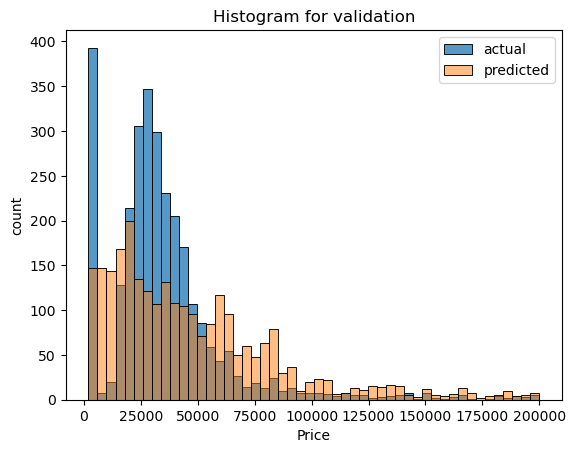

In [23]:
ax = sns.histplot(test["msrp"], bins=50, binrange=(df.msrp.min()-1, 2.e5), label='actual')
sns.histplot(LinearRegressionModel.predict(test.drop(columns=['msrp'])), bins=50, binrange=(df.msrp.min()-1, 2.e5), alpha=0.5, label='predicted')
ax.set(xlabel='Price', ylabel='count', title='Histogram for validation');
ax.legend();

As we can see, the price of the cars cannot be well described by a multi-linear model in terms of the involved parameters. We could now look at the categorical variables, for example, and use them to improve our model. Let's choose a categorical variable — the brand of the car, for example. We could add extra columns containing the names of the most frequent car brands and enter values of 0 or 1 to indicate whether or not the car is of that brand. This increases the number of variables in the model.

In [72]:
brands = df["make"].value_counts().head().index
extrafeatures = numframe.copy()

for v in brands:
  extrafeatures['make_%s' % v] = (df.make == v).astype('int')

In [73]:
train, test = train_test_split(extrafeatures, test_size=0.25)
LinearRegressionModel = LinearRegression().fit(train.drop(columns=['msrp']), train.msrp)

In [74]:
LinearRegressionModel.score(test.drop(columns=['msrp']), test.msrp)

0.5256647587090271

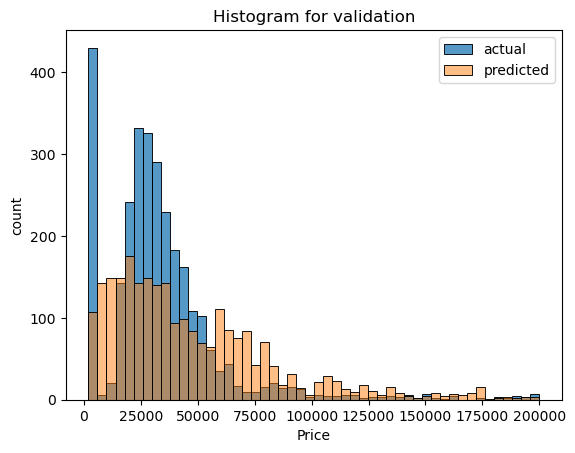

In [75]:
ax = sns.histplot(test["msrp"], bins=50, binrange=(df.msrp.min()-1, 2.e5), label='actual')
sns.histplot(LinearRegressionModel.predict(test.drop(columns=['msrp'])), bins=50, binrange=(df.msrp.min()-1, 2.e5), alpha=0.5, label='predicted')
ax.set(xlabel='Price', ylabel='count', title='Histogram for validation');
ax.legend();

In [41]:
LinearRegressionModel.score(test.drop(columns=['msrp']), test.msrp)

0.5087690961776125